# Random Forest Training & Evaluation

In this notebook we present the training and evaluation of a Random Forest model on the preprocessed dataset of tennis matches, described previously in `src/notebooks/preprocessing.ipynb`. 

The document is structured as follows:
- **Setup & Imports**: we import the necessary libraries and modules, and build the preprocessing pipeline.
- **Training & Fine-tuning**: we train the model and perform hyperparameter tuning
- **Evaluation**: we evaluate the model on the test set and analyze the results.

# Setup & Imports

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd().parent 
sys.path.append(str(PROJECT_ROOT))

from typing import cast

from src.data.loader import load_data, train_test_split
from src.data.preprocess import preprocessing_pipeline, create_labels
from src.data.transformers import DropFeatureSelector
from src.features.features import feature_engineering_pipeline
from src.training.training import training_pipeline, fine_tune, feature_selection_pipeline
from src.evaluation.metrics import feature_importance, cross_validation, evaluation_metrics, print_metrics
from src.evaluation.plots import plot_feature_importance, plot_roc_curve, plot_confusion_matrix
from src.utils.utils import get_best_estimator, TSCV

from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

In [2]:
df = load_data()
create_labels(df)
X_train, X_test, y_train, y_test = train_test_split(df)
prep_pipeline : Pipeline = preprocessing_pipeline(X_train, y_train)
feat_pipeline : Pipeline = feature_engineering_pipeline()

preprocessor = Pipeline(
    steps=[
        ("preprocessing", prep_pipeline),
        ("feature_engineering", feat_pipeline),
    ]
)

# Training & Fine Tuning

Firstly, we add the Random Forest Classifier as a step for the pipeline, then the we perform the fine tuning of the hyperparameters using a `GridSearchCV` with 5-fold cross validation.  

In [3]:
random_forest_train_pipeline = training_pipeline(model=RandomForestClassifier(random_state=42))

pipeline = Pipeline(
    steps = preprocessor.steps + random_forest_train_pipeline.steps
)

hyperparams = {
        'training__n_estimators': [100, 200, 300],
        'training__max_depth': [None, 10, 20],
        'training__min_samples_split': [2, 5, 10],
        'training__min_samples_leaf': [1, 2, 4]
    }

search_rf = fine_tune(
    pipeline=pipeline,
    tuning_methods=GridSearchCV,
    tscv=TSCV,
    hyperparams=hyperparams,
    scoring="accuracy",
    verbose=1,
    random_state=42
    )

search_rf.fit(X_train, y_train)

Fitting 5 folds for each of 81 candidates, totalling 405 fits


/Users/chetto/Desktop/Uni/ANNO-III/AI/Project/.venv/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'training__max_depth': [None, 10, ...], 'training__min_samples_leaf': [1, 2, ...], 'training__min_samples_split': [2, 5, ...], 'training__n_estimators': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",TimeSeriesSpl...est_size=None)
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` par

We derive the best estimator from the search, and we validate the model using cross-validation on the training set.

In [4]:
best_estimator = get_best_estimator(search_rf)

cross_val_scores = cross_validation(
        pipeline=best_estimator,
        X=X_train,
        y=y_train,
        tscv=TSCV,
        verbose=0,
        scoring="accuracy"
    )

print(pd.Series(cross_val_scores).describe())

count    5.000000
mean     0.676100
std      0.005125
min      0.671632
25%      0.672647
50%      0.674001
75%      0.678064
max      0.684157
dtype: float64


The classifier demonstrated moderate classification performance, achieving an average accuracy of 67% across five cross-validation folds. 
Its low standard deviation suggests that the model's performance is stable and relatively insensitive to the particular dataset on which it was trained.

## Feature Selection

The feature set generated after preprocessing contains many columns, some of which are redundant or weakly related to the target outcome. Thus, we can perform feature selection before the final Random Forest training, to improve generalization on unseen matches, reducing the noise and model complexity. 
Moreover, this method helps identify which tennis statistics are most informative for predicting the winner.

Initially, we extract the feature importance scores from the tuned Random Forest model. 

In [5]:
importances = feature_importance(
    pipeline=best_estimator,
    X=X_train
)

importances

,importance
avg_bet_diff,0.110273
max_bet_diff,0.096668
weighted_ranking_diff,0.049624
pts_diff,0.048923
weighted_pts_diff,0.044551
...,...
Tournament_Zhuhai Championships,0.000125
Tournament_Hong Kong Tennis Open,0.000121
Tournament_Chennai Open,0.000117
Tournament_Sydney Tennis Classic,0.000099


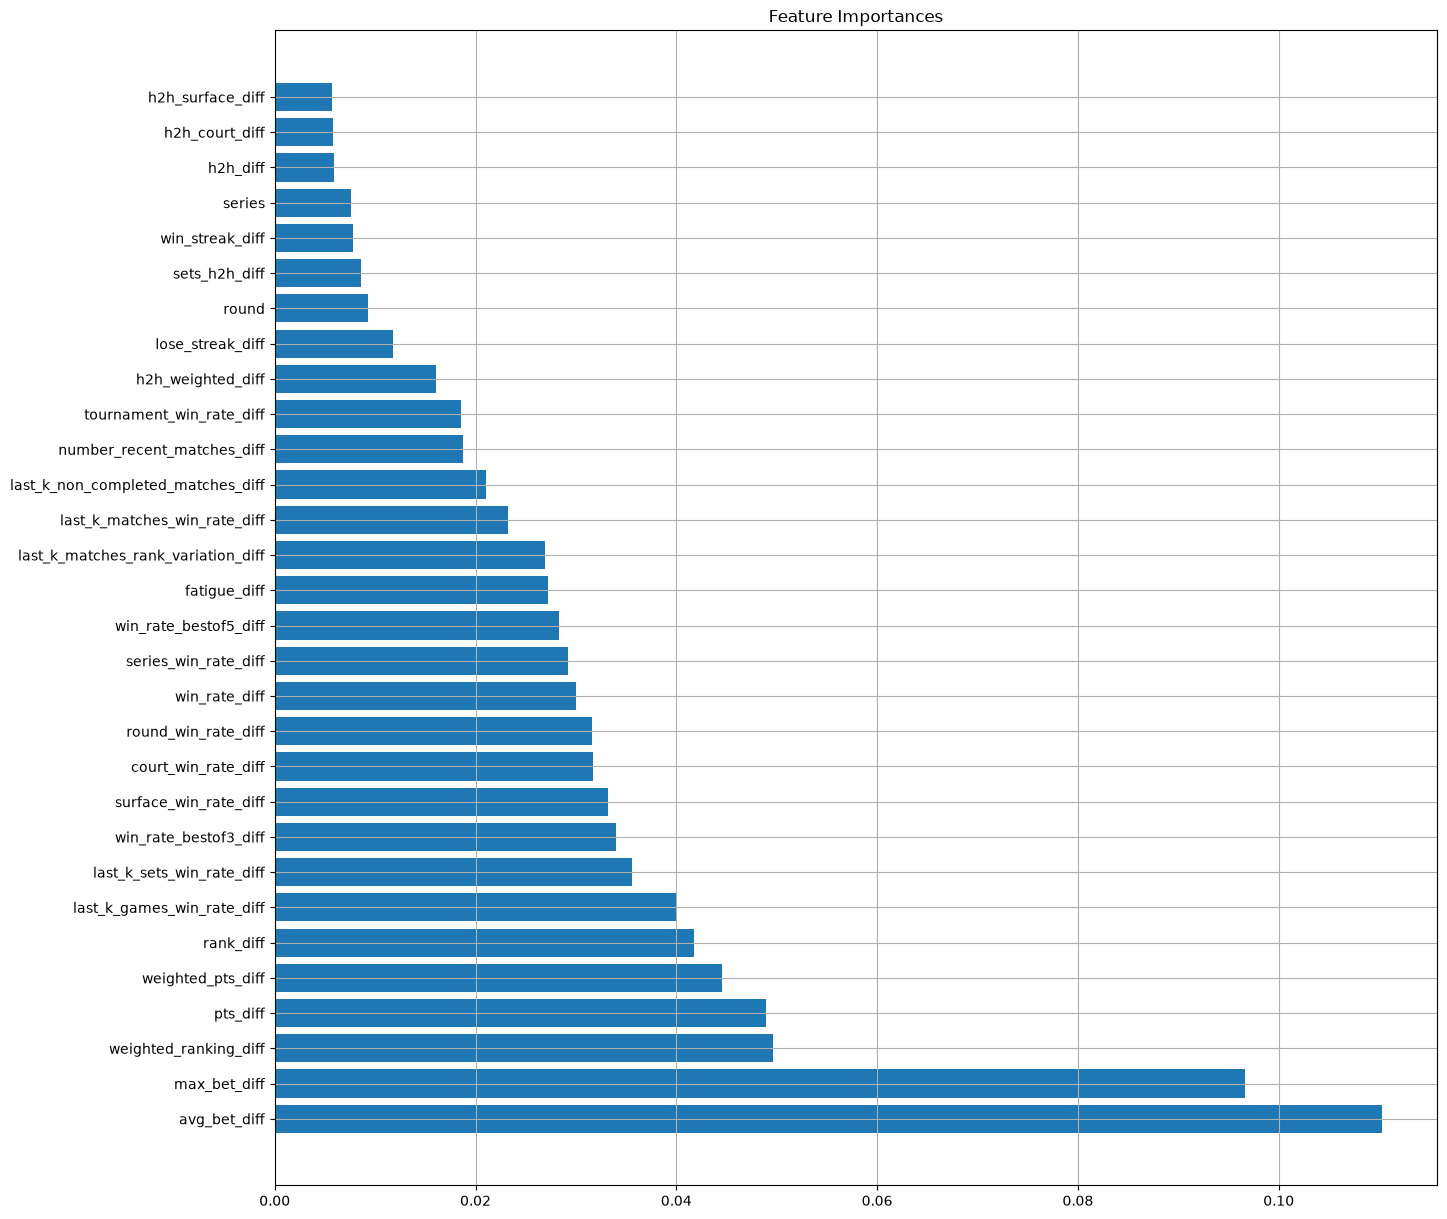

In [6]:
plot_feature_importance(
    feature_names=importances.index.tolist(),
    feature_importances=importances["importance"],
    top_n=30
)

Since the tournament ohe features look like they to be not very informative, firstly, we try to remove them and see the model performance by adding a `DropFeatureSelector` step to the pipeline. Then, we perform the same procedure for validating the model performance.

In [7]:
pipeline = Pipeline(
        steps= preprocessor.steps + [
            ("drop_tournaments", DropFeatureSelector(features_to_drop=["Tournament_"], is_grouped=True)),
            ] + random_forest_train_pipeline.steps
    )

search_rf = fine_tune(
    pipeline=pipeline,
    tuning_methods=GridSearchCV,
    tscv=TSCV,
    hyperparams=hyperparams,
    scoring="accuracy",
    verbose=0,
    random_state=42
    )

search_rf.fit(X_train, y_train)

/Users/chetto/Desktop/Uni/ANNO-III/AI/Project/.venv/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'training__max_depth': [None, 10, ...], 'training__min_samples_leaf': [1, 2, ...], 'training__min_samples_split': [2, 5, ...], 'training__n_estimators': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",TimeSeriesSpl...est_size=None)
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-v

In [8]:
best_estimator = get_best_estimator(search_rf)

cross_val_scores = cross_validation(
        pipeline=best_estimator,
        X=X_train,
        y=y_train,
        tscv=TSCV,
        verbose=0,
        scoring="accuracy"
    )

print(pd.Series(cross_val_scores).describe())

count    5.000000
mean     0.676506
std      0.006932
min      0.671632
25%      0.672647
50%      0.673663
75%      0.676032
max      0.688558
dtype: float64


In [9]:
len(feature_importance(pipeline=best_estimator, X=X_train))

38

The pipeline reduces the number of features to 38, and the best estimator of the search results still in a stable model, with slightly improved accuracy.

Now by adding a step for `RFECV` in the pipeline, we try to find the best subset of features for describing the target variable.

Here we use the `RandomizedSearchCV` method to find the best hyperparameters after subset selection.

In [10]:
rcevf_pipeline = feature_selection_pipeline(
    model=RandomForestClassifier(random_state=42),
    tscv=TSCV
)

pipeline = Pipeline(
    steps= preprocessor.steps + [
                ("drop_tournaments", DropFeatureSelector(features_to_drop=["Tournament_"], is_grouped=True)),
                ("fs", rcevf_pipeline),
            ] + random_forest_train_pipeline.steps
    )

In [ ]:
search_rf = fine_tune(
    pipeline=pipeline,
    tuning_methods=RandomizedSearchCV,
    tscv=TSCV,
    hyperparams=hyperparams,
    scoring="accuracy",
    verbose=0,
    random_state=42
)

search_rf.fit(X_train, y_train)

In [12]:
best_estimator = get_best_estimator(search_rf)

cross_val_scores = cross_validation(
        pipeline=best_estimator,
        X=X_train,
        y=y_train,
        tscv=TSCV,
        verbose=0,
        scoring="accuracy"
    )

print(pd.Series(cross_val_scores).describe())

count    5.000000
mean     0.673798
std      0.005939
min      0.667231
25%      0.670278
50%      0.671970
75%      0.677387
max      0.682126
dtype: float64


The accuracy of the model is similar to the previous one, then we can choose the model with less features.

Therefore we can construct and fit the full pipeline using the best estimator obtained from the search, and the `RFECV` step for feature selection.

In [13]:
full_pipeline_rf = best_estimator

# Evaluation

We evaluate the full pipeline on the test set.

In [14]:
y_pred = full_pipeline_rf.predict(X_test)

In [15]:
metrics : dict = evaluation_metrics(
    model=full_pipeline_rf,
    X_test=X_test,
    y_test=y_test,
    y_pred=y_pred
)

print_metrics(metrics)


Accuracy:
0.6790

Roc Auc:
0.7407

F1:
0.6679

Recall:
0.6634

Confusion Matrix:
      0     1
0  1590   702
1   731  1441


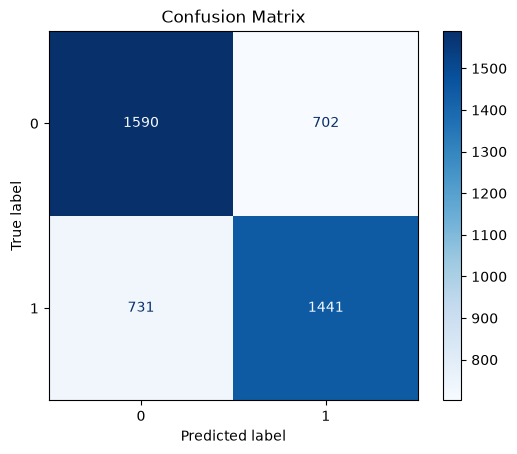

In [16]:
plot_confusion_matrix(cm=metrics["confusion_matrix"])

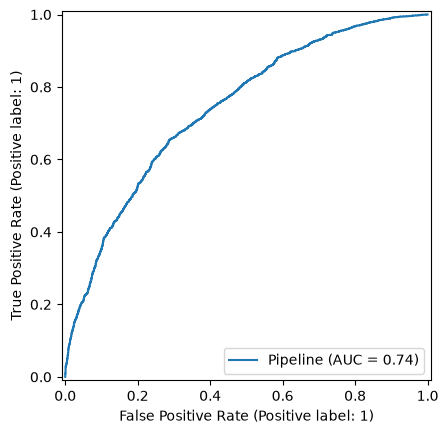

In [17]:
plot_roc_curve(
    model=full_pipeline_rf,
    X_test=X_test,
    y_test=y_test
)

Recall that the task is a binary classification problem with two players, thus, the goal of the model should be to predict correctly the most amount of matches outcome.
Therefore the main metrics to evaluate the generalization of the model are accuracy and roc-auc:
- The accuracy of the model on unseen matches is around 0.68, which is similar to the accuracy obtained during validation.
- The roc-auc score obtained reached 0.74.
- The confusion matrix shows that the model does not favor any player, since the difference between the number of false positives and false negatives is not significant.

### Incorrectly Predicted Matches

In conclusion, we investigate the distribution of wrongly predicted matches.

In [18]:
wrong = np.asarray(y_pred) != np.asarray(y_test)
X_test_transformed = full_pipeline_rf[:-1].transform(X_test)
errors = X_test_transformed[wrong].copy()
errors["y_true"] = np.asarray(y_test)[wrong]
errors["y_pred"] = np.asarray(y_pred)[wrong]
# errors["proba_pos"] = full_pipeline_rf.predict_proba(X_test)[:, 1]

player2_wins_wrong_pred = errors[(errors.y_true == 0) & (errors.y_pred == 1)] # player_2 actually won
player1_wins_wrong_pred = errors[(errors.y_true == 1) & (errors.y_pred == 0)] # player_1 actually won

player2_wins_wrong_pred.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
round,702.0,2.242165e+00,1.657917e+00,0.000000e+00,1.000000e+00,2.000000e+00,3.000000e+00,7.000000e+00
pts_diff,702.0,8.766040e+02,1.502816e+03,-6.059000e+03,-3.675000e+01,4.695000e+02,1.445750e+03,9.655000e+03
weighted_pts_diff,702.0,2.802262e+10,1.091615e+11,-3.710049e+11,-5.246230e+07,1.047335e+09,1.189545e+10,1.286075e+12
rank_diff,702.0,-4.356553e+01,1.196713e+02,-8.750000e+02,-6.500000e+01,-2.700000e+01,3.000000e+00,8.610000e+02
weighted_ranking_diff,702.0,7.187318e-02,1.235731e-01,-3.418861e-01,-3.717939e-03,4.345895e-02,1.138106e-01,8.509288e-01
win_rate_diff,702.0,-1.110093e-01,3.054283e-01,-1.646465e+00,-2.883513e-01,-1.061476e-01,5.966527e-02,1.500000e+00
max_bet_diff,702.0,-1.650698e+00,2.170907e+00,-3.283000e+01,-2.137500e+00,-1.080000e+00,-6.000000e-01,1.020000e+00
avg_bet_diff,702.0,-1.430185e+00,1.610653e+00,-1.806000e+01,-1.970000e+00,-9.750000e-01,-5.500000e-01,9.100000e-01
fatigue_diff,702.0,-1.680905e-02,1.515685e-01,-5.480793e-01,-9.494598e-02,-4.760176e-03,5.590900e-02,7.906438e-01
last_k_matches_win_rate_diff,702.0,7.898860e-02,1.396709e-01,-3.500000e-01,0.000000e+00,1.000000e-01,1.500000e-01,5.500000e-01


The distribution of the incorrectly predicted matches, i.e., matches in which Player 2 was the actual winner, suggests that the model tends to misclassify these matches because the player_1 seems to have better statistics than player_2.

For example, considering the features in order of importance, we obtain the following median values:
- `player1_Max` < `player2_Max` $\rightarrow$ `max_bet_diff` < 0
- `player1_Avg` < `player2_Avg` $\rightarrow$ `avg_bet_diff` < 0
- `player1_Rank` < `player2_Rank` $\rightarrow$ `rank_diff` < 0
- `player1_Pts` > `player2_Pts` $\rightarrow$ `pts_diff` > 0

In [19]:
correct = X_test_transformed[~wrong].copy()
correct["y_true"] = np.asarray(y_test)[~wrong]
correct["y_pred"] = np.asarray(y_pred)[~wrong]

player2_wins_right_pred = correct[(correct.y_true == 0) & (correct.y_pred == 0)] # player_2 actually won
player1_wins_right_pred = correct[(correct.y_true == 1) & (correct.y_pred == 1)] # player_1 actually won

player2_wins_right_pred.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
round,1590.0,2.272956e+00,1.614039e+00,0.000000e+00,1.000000e+00,2.000000e+00,3.000000e+00,7.000000e+00
pts_diff,1590.0,-1.395303e+03,2.100894e+03,-1.160000e+04,-2.037750e+03,-7.050000e+02,-8.100000e+01,5.535000e+03
weighted_pts_diff,1590.0,-7.250226e+10,2.391833e+11,-1.740913e+12,-2.687984e+10,-2.271429e+09,-9.031925e+07,9.014037e+11
rank_diff,1590.0,5.297233e+01,1.176325e+02,-6.420000e+02,5.000000e+00,3.200000e+01,7.400000e+01,1.370000e+03
weighted_ranking_diff,1590.0,-1.112115e-01,1.722808e-01,-9.166667e-01,-1.580822e-01,-6.343119e-02,-7.838468e-03,6.220355e-01
win_rate_diff,1590.0,1.511741e-01,3.047680e-01,-1.158730e+00,-3.219082e-02,1.365689e-01,3.273148e-01,1.638037e+00
max_bet_diff,1590.0,3.137258e+00,5.798785e+00,-7.600000e-01,7.000000e-01,1.580000e+00,3.250000e+00,8.899000e+01
avg_bet_diff,1590.0,2.424824e+00,3.192004e+00,-7.200000e-01,6.300000e-01,1.430000e+00,2.917500e+00,2.841000e+01
fatigue_diff,1590.0,2.712265e-02,1.485476e-01,-7.018306e-01,-4.720308e-02,1.624314e-02,9.784464e-02,5.924037e-01
last_k_matches_win_rate_diff,1590.0,-1.063679e-01,1.564054e-01,-7.000000e-01,-2.000000e-01,-1.000000e-01,0.000000e+00,4.000000e-01


Conversely, when looking at the distribution of the correctly predicted matches, i.e., matches in which Player 2 was the actual winner, we can observe that the model tends to classify them correctly because the median values of the previously analyzed features generally have the opposite sign. This indicates that, in these cases, the players' statistics mostly favor Player 2, providing evidence consistent with the actual outcome of the match.